In [ ]:
# Mount into drive
import time
import copy
import pathlib
import os

from google.colab import drive

drive.mount("/content/drive")

%cd '/content/drive/MyDrive/CS7643/FinalProject/'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/18DzphWfHEkGdHaXfkSrWGl0v37qf7tZ-/FinalProject


In [ ]:
import torch
DEVICE= torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("USING device :",DEVICE)


USING device : cuda


In [ ]:
# relevant imports
import pandas as pd
import numpy as np
import torch
from PIL import Image
import io
import pathlib
import time
import copy
import matplotlib.pyplot as plt
import torchvision
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
from torch.nn import Parameter

In [ ]:

class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def check_accuracy(output, target):
    """Computes the precision@k for the specified values of k"""
    batch_size = target.shape[0]

    _, pred = torch.max(output, dim=-1)

    correct = pred.eq(target).sum().item() #* 1.0

    acc = correct / batch_size

    return acc, pred

class Trainer(object):
    def __init__(self, model, optimizer,criterion, config):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.config = config
        self.save_best = True
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.scheduler = None
        if config['scheduler']['set_scheduler']:
            self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                        self.optimizer,
                        mode='min',
                        factor=config['scheduler']['factor'],
                        patience=config['scheduler']['patience'],
                        verbose=True,
                        min_lr=config['scheduler']['min_lr']
                    )

        print("USING device :", self.device)
        self.model = self.model.to(self.device)
        self.criterion = self.criterion.to(self.device)
        save_dir = f"checkpoints/{self.config['model_name']}"
        basedir = pathlib.Path().parent.resolve()
        checkpoint_path = pathlib.Path(basedir/save_dir)
        self.checkpoint_path = checkpoint_path

    def train_step(self, epoch):
        iter_time = AverageMeter()
        losses = AverageMeter()
        acc = AverageMeter()

        self.model.train()

        for idx, (data, target) in enumerate(train_loader):
            start = time.time()

            data = data.to(self.device)
            target = target.to(self.device)

            self.optimizer.zero_grad()
            out = self.model(data)
            batch_acc, pred = check_accuracy(out, target.squeeze(1))
            loss = criterion(out, target.squeeze(1).long())
            loss.backward()
            self.optimizer.step()

            losses.update(loss.item(), out.shape[0])
            acc.update(batch_acc, out.shape[0])

            iter_time.update(time.time() - start)
            if idx % 10 == 0:
                print(
                    (
                        "Epoch: [{0}][{1}/{2}]\t"
                        "Time {iter_time.val:.3f} ({iter_time.avg:.3f})\t"
                        "Loss {loss.val:.4f} ({loss.avg:.4f})\t"
                        "Prec @1 {top1.val:.4f} ({top1.avg:.4f})\t"
                    ).format(
                        epoch,
                        idx,
                        len(train_loader),
                        iter_time=iter_time,
                        loss=losses,
                        top1=acc,
                    )
                )
        return acc.avg, losses.avg

    def evaluate_step(self, epoch):
        iter_time = AverageMeter()
        losses = AverageMeter()
        acc = AverageMeter()

        num_class = self.config['num_classes']
        cm = torch.zeros(num_class, num_class)
        self.model.eval()

        # evaluation loop

        for idx, (data, target) in enumerate(val_loader):
            start = time.time()

            data = data.to(self.device)
            target = target.to(self.device)
            with torch.no_grad():
                out = self.model(data)
                batch_acc, pred = check_accuracy(out, target.squeeze(1).long())
                loss = criterion(out, target.squeeze(1).long())

            # update confusion matrix
            _, preds = torch.max(out, 1)
            for t, p in zip(target.view(-1), preds.view(-1)):
                cm[t.long(), p.long()] += 1

            losses.update(loss.item(), out.shape[0])
            acc.update(batch_acc, out.shape[0])

            iter_time.update(time.time() - start)
            if idx % 10 == 0:
                print(
                    (
                        "Epoch: [{0}][{1}/{2}]\t"
                        "Time {iter_time.val:.3f} ({iter_time.avg:.3f})\t"
                    ).format(
                        epoch,
                        idx,
                        len(val_loader),
                        iter_time=iter_time,
                        loss=losses,
                        top1=acc,
                    )
                )
        cm = cm / cm.sum(1)
        per_cls_acc = cm.diag().detach().numpy().tolist()
        for i, acc_i in enumerate(per_cls_acc):
            print("Accuracy of Class {}: {:.4f}".format(i, acc_i))

        print("* Prec @1: {top1.avg:.4f}".format(top1=acc))
        return cm, acc.avg, losses.avg

    def test_step(self):
        iter_time = AverageMeter()
        losses = AverageMeter()
        acc = AverageMeter()

        num_class = self.config['num_classes']
        cm = torch.zeros(num_class, num_class)
        self.model.eval()

        # evaluation loop

        for idx, (data, target) in enumerate(test_loader):
            start = time.time()

            data = data.to(self.device)
            target = target.to(self.device)
            with torch.no_grad():
                out = self.model(data)
                batch_acc, pred = check_accuracy(out, target.squeeze(1).long())
                loss = criterion(out, target.squeeze(1).long())

            # update confusion matrix
            _, preds = torch.max(out, 1)
            for t, p in zip(target.view(-1), preds.view(-1)):
                cm[t.long(), p.long()] += 1

            losses.update(loss.item(), out.shape[0])
            acc.update(batch_acc, out.shape[0])

            iter_time.update(time.time() - start)
            if idx % 10 == 0:
                print(
                    (
                      "Time {iter_time.val:.3f} ({iter_time.avg:.3f})\t"
                    ).format(
                        iter_time=iter_time,
                        loss=losses,
                        top1=acc,
                    )
                )
        cm = cm / cm.sum(1)
        per_cls_acc = cm.diag().detach().numpy().tolist()
        for i, acc_i in enumerate(per_cls_acc):
            print("Accuracy of Class {}: {:.4f}".format(i, acc_i))

        print("* Prec @1: {top1.avg:.4f}".format(top1=acc))
        return cm, acc, losses


    def train(self):
        best = 0
        best_cm = None
        best_model = None
        train_losses = []
        train_accs = []
        val_losses = []
        val_accs = []
        for epoch in range(self.config['epochs']):

            # train loop
            train_acc, train_loss = self.train_step(epoch)

            # validation loop
            cm,acc,loss = self.evaluate_step(epoch)

            current_lr = self.optimizer.param_groups[0]['lr']
            print('current_learning_rate', current_lr)
            if self.scheduler:
                self.scheduler.step(loss)

            if acc > best:
                best = acc
                best_cm = cm
                best_model = copy.deepcopy(model)
            train_losses.append(train_loss)
            train_accs.append(train_acc)
            val_losses.append(loss)
            val_accs.append(acc)
        print("Best Prec @1 Acccuracy: {:.4f}".format(best))
        per_cls_acc = best_cm.diag().detach().numpy().tolist()
        for i, acc_i in enumerate(per_cls_acc):
            print("Accuracy of Class {}: {:.4f}".format(i, acc_i))

        if self.save_best:
            if not pathlib.Path(self.checkpoint_path).exists():
                pathlib.Path(self.checkpoint_path).mkdir(parents=True, exist_ok=True)
                print(f"Directory {self.checkpoint_path} created successfully")
            else:
                print(f"Directory {self.checkpoint_path} already exists")

            torch.save(
                best_model.state_dict(),
                str(self.checkpoint_path) + "/model_checkpoint.pth",
            )

        epochs = range(len(train_losses))
        plt.plot(epochs, train_losses, label='train')
        plt.plot(epochs, val_losses, label='valid')

        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Loss Curve')
        plt.savefig(str(self.checkpoint_path)+'/loss_curve.png')
        plt.show()
        plt.plot(epochs, train_accs, label='train')
        plt.plot(epochs, val_accs, label='valid')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title('Accuracy Curve')
        plt.savefig(str(self.checkpoint_path)+'/accuracy_curve.png')
        plt.show()

In [ ]:

def _weights_init(m):
    classname = m.__class__.__name__
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        init.kaiming_normal_(m.weight)

class NormedLinear(nn.Module):

    def __init__(self, in_features, out_features):
        super(NormedLinear, self).__init__()
        self.weight = Parameter(torch.Tensor(in_features, out_features))
        self.weight.data.uniform_(-1, 1).renorm_(2, 1, 1e-5).mul_(1e5)

    def forward(self, x):
        out = F.normalize(x, dim=1).mm(F.normalize(self.weight, dim=0))
        return out

class LambdaLayer(nn.Module):

    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, option='A'):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            if option == 'A':
                """
                For CIFAR10 ResNet paper uses option A.
                """
                self.shortcut = LambdaLayer(lambda x:
                                            F.pad(x[:, :, ::2, ::2], (0, 0, 0, 0, planes//4, planes//4), "constant", 0))
            elif option == 'B':
                self.shortcut = nn.Sequential(
                     nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                     nn.BatchNorm2d(self.expansion * planes)
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet_s(nn.Module):

    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_s, self).__init__()
        self.in_planes = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)

        self.linear = nn.Linear(64, num_classes)
        self.apply(_weights_init)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[3])
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def resnet32(num_classes=10, use_norm=False):
    return ResNet_s(BasicBlock, [5, 5, 5], num_classes=num_classes)




In [ ]:
import yaml
with open('config.yaml', 'r') as file:
    cfg = yaml.safe_load(file)
print(cfg)

{'model_name': 'resnet152', 'batch_size': 256, 'epochs': 15, 'lr': 0.0001, 'scheduler': {'set_scheduler': True, 'patience': 5, 'factor': 0.5, 'min_lr': 1e-06}, 'num_classes': 20, 'size': 224, 'n_classes': 20, 'weight_decay': 0.0001}


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


testing download


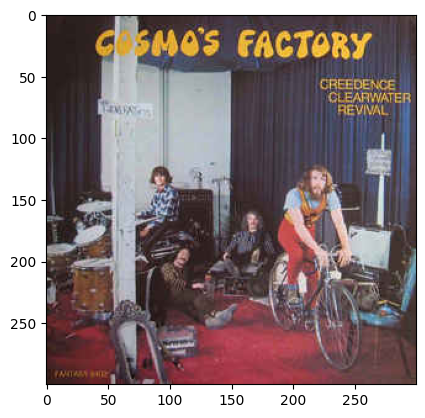

torch.Size([3, 224, 224])
tensor([[[-1.3815, -1.3815, -1.3815,  ..., -0.6794, -0.7137, -0.0287],
         [-1.3815, -1.3815, -1.3815,  ..., -0.7479, -0.7993, -0.2684],
         [-1.3815, -1.3815, -1.3815,  ..., -0.6965, -0.7993, -0.5767],
         ...,
         [-1.2445, -1.2274, -1.2103,  ..., -0.5938, -0.5767, -0.5253],
         [-1.2445, -1.2274, -1.2103,  ..., -0.5767, -0.5596, -0.4911],
         [-1.2445, -1.2274, -1.2103,  ..., -0.4397, -0.4054, -0.3198]],

        [[-1.4580, -1.4580, -1.4580,  ..., -0.8102, -0.8452, -0.1450],
         [-1.4580, -1.4580, -1.4580,  ..., -0.8803, -0.9328, -0.3901],
         [-1.4580, -1.4580, -1.4580,  ..., -0.8452, -0.9503, -0.7052],
         ...,
         [-1.5105, -1.5105, -1.4930,  ..., -0.9153, -0.8803, -0.8102],
         [-1.5105, -1.4930, -1.4755,  ..., -0.9153, -0.8803, -0.7927],
         [-1.5105, -1.4930, -1.4755,  ..., -0.7752, -0.7227, -0.6352]],

        [[-1.2641, -1.2641, -1.2641,  ..., -0.7936, -0.8458, -0.1487],
         [-1.2641, 

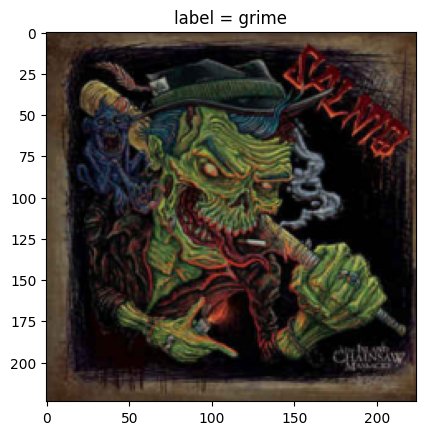

{0: 'blues', 1: 'classical', 2: 'country', 3: 'deathmetal', 4: 'doommetal', 5: 'drumnbass', 6: 'electronic', 7: 'folk', 8: 'grime', 9: 'heavymetal', 10: 'hiphop', 11: 'jazz', 12: 'lofi', 13: 'pop', 14: 'psychedelicrock', 15: 'punk', 16: 'reggae', 17: 'rock', 18: 'soul', 19: 'techno'}


(torch.Size([16000, 3, 224, 224]), torch.Size([4000, 3, 224, 224]))

In [ ]:
# gets the data and creates the train/test splits
import data_loader

dl = data_loader.DataLoader(size=cfg['size'], use_fraction=1)
dl.main()
# get the  train and test images/labels
train_images, train_labels = dl.return_train_data()
test_images, test_labels = dl.return_test_data()
label_names = dl.labelNames

del dl
print(label_names)
train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)
train_images.shape, test_images.shape


In [ ]:
cfg['model_name'] ='resnet32'

In [ ]:
from torchvision.models import resnet

if cfg['model_name'] =='resnet152':
    model = resnet.resnet152(weights=resnet.ResNet152_Weights.IMAGENET1K_V1)
    num_ftrs = model.fc.in_features
    # Here the size of each output sample is set to 2.
    # Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
    model.fc = nn.Linear(num_ftrs, cfg['num_classes'])
    for param in model.parameters():
        param.requires_grad = False
    model.fc.weight.requires_grad = True
    model.fc.bias.requires_grad = True
elif cfg['model_name'] =='resnet32':
    model = resnet32(num_classes=cfg['num_classes'])

# model = model.to(device)

from torchsummary import summary
import torch.optim as optim

criterion=nn.CrossEntropyLoss()

train_loader = DataLoader(train_dataset, batch_size=cfg['batch_size'], shuffle=True)

val_loader = DataLoader(test_dataset, batch_size=cfg['batch_size'], shuffle=False)
# Define the optimizer (Adam)
optimizer = optim.Adam(model.parameters(),lr=cfg['lr'], weight_decay=cfg['weight_decay'])
criterion = nn.CrossEntropyLoss()
trainer = Trainer(model, optimizer, criterion,config=cfg)
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


USING device : cuda
Epoch: [0][0/63]	Time 0.941 (0.941)	Loss 5.9298 (5.9298)	Prec @1 0.0547 (0.0547)	
Epoch: [0][10/63]	Time 0.923 (0.925)	Loss 4.5753 (5.1856)	Prec @1 0.0547 (0.0533)	
Epoch: [0][20/63]	Time 0.924 (0.924)	Loss 4.0757 (4.7646)	Prec @1 0.0508 (0.0513)	
Epoch: [0][30/63]	Time 0.926 (0.924)	Loss 3.6914 (4.4708)	Prec @1 0.0430 (0.0496)	
Epoch: [0][40/63]	Time 0.925 (0.924)	Loss 3.5669 (4.2509)	Prec @1 0.0469 (0.0510)	
Epoch: [0][50/63]	Time 0.925 (0.924)	Loss 3.4709 (4.0826)	Prec @1 0.0781 (0.0538)	
Epoch: [0][60/63]	Time 0.924 (0.924)	Loss 3.1935 (3.9478)	Prec @1 0.0625 (0.0553)	
Epoch: [0][0/16]	Time 0.200 (0.200)	
Epoch: [0][10/16]	Time 0.201 (0.201)	
Accuracy of Class 0: 0.0000
Accuracy of Class 1: 0.3098
Accuracy of Class 2: 0.0000
Accuracy of Class 3: 0.0386
Accuracy of Class 4: 0.0000
Accuracy of Class 5: 0.4586
Accuracy of Class 6: 0.0632
Accuracy of Class 7: 0.0191
Accuracy of Class 8: 0.0000
Accuracy of Class 9: 0.0000
Accuracy of Class 10: 0.0825
Accuracy of Clas

In [ ]:
import torch

def compute_metrics_from_confusion_matrix(cm):
    """
    cm: torch.Tensor of shape (num_classes, num_classes)
    returns: dict with precision, recall, f1 per class
    """
    num_classes = cm.shape[0]
    metrics = {}

    eps = 1e-8  # small epsilon to avoid divide by zero

    TP = cm.diag()
    FP = cm.sum(0) - TP
    FN = cm.sum(1) - TP
    TN = cm.sum() - (TP + FP + FN)

    precision = TP / (TP + FP + eps)
    recall = TP / (TP + FN + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    metrics['precision_per_class'] = precision
    metrics['recall_per_class'] = recall
    metrics['f1_per_class'] = f1
    metrics['accuracy_per_class'] = TP / (TP + FN + eps)

    # Also compute macro-averaged scores
    metrics['macro_precision'] = precision.mean()
    metrics['macro_recall'] = recall.mean()
    metrics['macro_f1'] = f1.mean()
    metrics['overall_accuracy'] = TP.sum() / cm.sum()

    return metrics


In [ ]:
cm, acc, loss = Trainer.evaluate_step(trainer,1)
compute_metrics_from_confusion_matrix(cm)

Epoch: [1][0/16]	Time 0.200 (0.200)	
Epoch: [1][10/16]	Time 0.202 (0.201)	
Accuracy of Class 0: 0.0118
Accuracy of Class 1: 0.3587
Accuracy of Class 2: 0.1443
Accuracy of Class 3: 0.4976
Accuracy of Class 4: 0.2150
Accuracy of Class 5: 0.0221
Accuracy of Class 6: 0.0474
Accuracy of Class 7: 0.1053
Accuracy of Class 8: 0.2212
Accuracy of Class 9: 0.0415
Accuracy of Class 10: 0.0000
Accuracy of Class 11: 0.2374
Accuracy of Class 12: 0.0321
Accuracy of Class 13: 0.0050
Accuracy of Class 14: 0.0332
Accuracy of Class 15: 0.1256
Accuracy of Class 16: 0.0800
Accuracy of Class 17: 0.0000
Accuracy of Class 18: 0.0104
Accuracy of Class 19: 0.1111
* Prec @1: 0.1163


{'precision_per_class': tensor([0.1176, 0.0991, 0.0822, 0.1767, 0.1077, 0.0800, 0.1169, 0.0866, 0.1608,
         0.1860, 0.0000, 0.0835, 0.0968, 0.0286, 0.2059, 0.1281, 0.1185, 0.0000,
         0.0556, 0.1524]),
 'recall_per_class': tensor([0.0138, 0.3808, 0.1429, 0.4930, 0.2059, 0.0246, 0.0502, 0.1003, 0.2159,
         0.0432, 0.0000, 0.2398, 0.0344, 0.0050, 0.0317, 0.1216, 0.0797, 0.0000,
         0.0108, 0.1003]),
 'f1_per_class': tensor([0.0246, 0.1573, 0.1043, 0.2601, 0.1415, 0.0377, 0.0702, 0.0929, 0.1843,
         0.0701, 0.0000, 0.1238, 0.0507, 0.0085, 0.0549, 0.1248, 0.0953, 0.0000,
         0.0181, 0.1210]),
 'accuracy_per_class': tensor([0.0138, 0.3808, 0.1429, 0.4930, 0.2059, 0.0246, 0.0502, 0.1003, 0.2159,
         0.0432, 0.0000, 0.2398, 0.0344, 0.0050, 0.0317, 0.1216, 0.0797, 0.0000,
         0.0108, 0.1003]),
 'macro_precision': tensor(0.1041),
 'macro_recall': tensor(0.1147),
 'macro_f1': tensor(0.0870),
 'overall_accuracy': tensor(0.1154)}

In [1]:
# 0: 'blues', 1: 'classical', 2: 'country', 3: 'deathmetal', 4: 'doommetal', 5: 'drumnbass', 6: 'electronic', 7: 'folk', 8: 'grime', 9: 'heavymetal', 10: 'hiphop', 11: 'jazz', 12: 'lofi', 13: 'pop', 14: 'psychedelicrock', 15: 'punk', 16: 'reggae', 17: 'rock', 18: 'soul', 19: 'techno'}
